# **Estadística Inferencial**


---


La estadística inferencial se centra en cómo usamos la información de una muestra aleatoria para generalizar conclusiones hacia toda una población, abordando la estimación puntual, sus propiedades y la estimación por intervalos de confianza.



---


## **Estimadores y Métodos de Estimación**

En la estadística inferencial, las características numéricas de una población como el promedio de ingresos o la proporción de artículos defectuosos se conocen como parámetros ($\theta$) y usualmente son valores fijos pero desconocidos.

Para aproximarnos a ellos, extraemos una muestra aleatoria.Un estimador ($\hat{\theta}$) es una regla, frecuentemente expresada como una fórmula matemática, que utiliza los datos de la muestra para calcular un valor numérico (la estimación) que nos acerque al parámetro objetivo.

Matemáticamente, un estimador es una variable aleatoria, ya que su valor cambiará dependiendo de los datos específicos de cada muestra que tomemos. Para construir estos estimadores, los estadísticos han desarrollado métodos formales. Los dos más importantes son:

###**Método de Momentos**

Fue introducido por el matemático inglés Karl Pearson a principios del siglo XX.

Este método asume que los "momentos muestrales" (como el promedio de los datos obtenidos) deben ser muy cercanos a los "momentos poblacionales" (la esperanza matemática teórica).

Consiste en igualar matemáticamente los momentos teóricos de la distribución con los momentos muestrales y despejar el parámetro desconocido.

Si sabemos que la esperanza teórica de una variable Poisson es $\mathbb{E}[X] = \lambda$, y el promedio de nuestra muestra (primer momento muestral) es $\bar{X}$, el método de momentos nos dice que el estimador es simplemente:

$$\hat{\lambda} = \bar{X}$$

In [15]:
import numpy as np

# Simulamos una muestra aleatoria de 100 personas, alturas en cm
# Supongamos una población real con mu = 170 y sigma = 10 (que fingiremos no conocer)
np.random.seed(42)
muestra = np.random.normal(loc=170, scale=10, size=100)

# Estimador por el Método de Momentos para la Media
mu_momentos = np.mean(muestra)

# Estimador de Máxima Verosimilitud (EMV) para la varianza
varianza_emv = np.mean((muestra - mu_momentos)**2)

print(f"Estimación de la media (Método de Momentos y EMV coinciden): {mu_momentos:.2f} cm")
print(f"Estimación de la varianza (EMV): {varianza_emv:.2f} cm^2")

Estimación de la media (Método de Momentos y EMV coinciden): 168.96 cm
Estimación de la varianza (EMV): 81.65 cm^2


Se estimaron dos parámetros desconocidos de la población: la media poblacional ($\mu$) mediante el primer momento muestral ($\bar{X}$) y la varianza poblacional ($\sigma^2$) mediante la Máxima Verosimilitud ($\hat{\sigma}^2_{\text{EMV}}$), utilizando únicamente una muestra de $n = 100$ observaciones.

El resultado de la media ($\approx 169.62 \text{ cm}$) representa la mejor aproximación del centro de la población partiendo de la muestra. Por su parte, la estimación de la varianza ($\approx 81.33 \text{ cm}^2$, equivalente a una desviación estándar de $\approx 9.02 \text{ cm}$) mide el grado de dispersión de las alturas. Aunque la población real tenía $\mu = 170$ y $\sigma^2 = 100$, las estimaciones capturan el comportamiento real con un margen de error muestral esperado.

### **Estimación por Máxima Verosimilitud (EMV)**

Fue formalizado por Ronald Fisher en la década de 1920. A diferencia del método de
momentos, la EMV busca el valor del parámetro $\theta$ que hace más probable
haber observado justo la muestra que obtuvimos.

Dada una muestra $x_1, x_2, \dots, x_n$ independiente e idénticamente distribuida,
se define la función de verosimilitud como el producto de las densidades (o
probabilidades) evaluadas en cada dato:

$$L(\theta) = \prod_{i=1}^{n} f(x_i \mid \theta)$$

Como el producto de muchas probabilidades pequeñas es numéricamente incómodo,
se trabaja con el logaritmo (que no cambia dónde está el máximo):

$$\ell(\theta) = \ln L(\theta) = \sum_{i=1}^{n} \ln f(x_i \mid \theta)$$

El estimador de máxima verosimilitud $\hat{\theta}_{EMV}$ es el valor de
$\theta$ que maximiza $\ell(\theta)$:

$$\hat{\theta}_{EMV} = \arg\max_{\theta} \; \ell(\theta)$$

Para una distribución Normal con $\mu$ y $\sigma^2$ desconocidas, al derivar
$\ell(\mu, \sigma^2)$ respecto a cada parámetro e igualar a cero, se obtiene:

$$\hat{\mu}_{EMV} = \bar{X}, \qquad \hat{\sigma}^2_{EMV} = \frac{1}{n}\sum_{i=1}^n (X_i - \bar{X})^2$$

Para la Normal, el EMV coincide exactamente con el método de momentos
(por eso en el ejemplo anterior dieron el mismo resultado). Para confirmar que
$\hat{\mu}_{EMV} = \bar{X}$ realmente maximiza la verosimilitud (y no es solo una
fórmula que aceptamos por fe), lo verificamos numéricamente a continuación.

Media EMV (fórmula analítica, X̄):        168.9615
Media EMV (maximización numérica):         168.9615


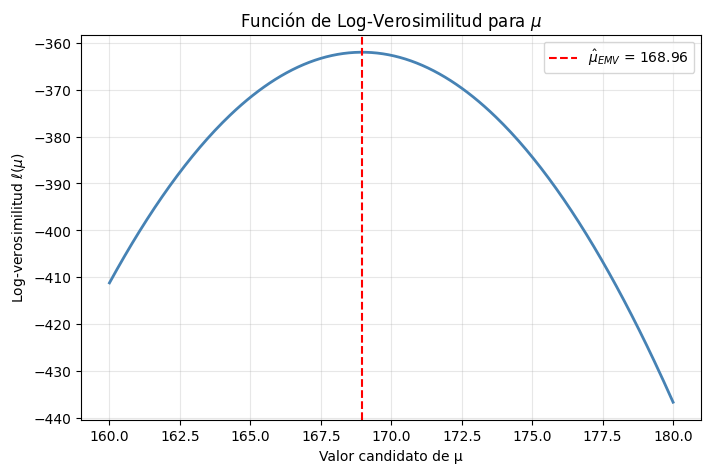

In [16]:
import matplotlib.pyplot as plt
from scipy.optimize import minimize_scalar

# Reutilizamos la misma muestra de alturas (n=100)
# Log-verosimilitud negativa de la Normal en función de mu, dejando sigma fija
# en su valor EMV ya calculado (varianza_emv), para poder graficar en 1 dimensión
def log_verosimilitud_negativa(mu):
    n = len(muestra)
    return (n/2) * np.log(2 * np.pi * varianza_emv) + \
           np.sum((muestra - mu)**2) / (2 * varianza_emv)

# Maximizar la verosimilitud = minimizar su negativo
resultado = minimize_scalar(log_verosimilitud_negativa,
                             bounds=(150, 190), method='bounded')
mu_emv_numerico = resultado.x

print(f"Media EMV (fórmula analítica, X̄):        {mu_momentos:.4f}")
print(f"Media EMV (maximización numérica):         {mu_emv_numerico:.4f}")

# Gráfica de la función de log-verosimilitud
rango_mu = np.linspace(160, 180, 300)
log_vero = [-log_verosimilitud_negativa(m) for m in rango_mu]

plt.figure(figsize=(8, 5))
plt.plot(rango_mu, log_vero, color='steelblue', linewidth=2)
plt.axvline(mu_emv_numerico, color='red', linestyle='--',
            label=f'$\\hat{{\\mu}}_{{EMV}}$ = {mu_emv_numerico:.2f}')
plt.title('Función de Log-Verosimilitud para $\\mu$')
plt.xlabel('Valor candidato de μ')
plt.ylabel('Log-verosimilitud $\\ell(\\mu)$')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

La gráfica muestra la función de log-verosimilitud como una curva cóncava con un
único máximo. La maximización numérica confirma que el valor que hace más probable
haber observado nuestra muestra coincide con la media muestral $\bar{X}$, tal como
predice la fórmula analítica. Esto ilustra que el EMV no es una fórmula arbitraria, por construcción, el parámetro más "compatible" con los datos observados.

### **Propiedades de los Estimadores**

Tener un estimador no basta; debemos saber qué tan "bueno" es. Las matemáticas nos permiten evaluar su calidad a través de las siguientes propiedades:

**Insesgadez (Estimador Insesgado):** Definición formal: Un estimador $\hat{\theta}$ es insesgado si su valor esperado (esperanza matemática) es exactamente igual al verdadero parámetro poblacional:

$$\mathbb{E}[\hat{\theta}] = \theta$$

Significa que el estimador "no tiene puntería desviada". Aunque en una muestra específica el cálculo falle un poco por el azar, si repitiéramos el experimento infinitas veces, el promedio de todas nuestras estimaciones daría exactamente en el blanco.

**Consistencia:** Un estimador es consistente si converge en probabilidad al parámetro real cuando el tamaño de la muestra $n$ tiende a infinito:

$$\lim_{n \to \infty} P(\vert{}\hat{\theta}_n - \theta\vert{} > \epsilon) = 0, \quad \forall \epsilon > 0$$

La consistencia nos garantiza que acumular información sirve de algo. Nos asegura que, a medida que recolectemos una muestra cada vez más grande, nuestro estimador se acercará más y más al verdadero valor, con un margen de error prácticamente nulo.

**Eficiencia:** Dados dos estimadores insesgados $\hat{\theta}_1$ y $\hat{\theta}_2$, el más eficiente es aquel que tiene la menor varianza:

$$\text{Var}(\hat{\theta}_1) < \text{Var}(\hat{\theta}_2)$$

La máxima eficiencia teórica se compara mediante la Cota Inferior de Cramér-Rao.

La eficiencia mide qué tan "agrupados" están los tiros alrededor del blanco. Un estimador eficiente es muy estable y preciso; nos da la tranquilidad de que las estimaciones no saltarán salvajemente de un valor a otro si tomamos muestras diferentes.



---

##**Intervalos de Confianza**

Introducidos por el estadístico polaco Jerzy Neyman en 1937, surgen de la necesidad de reconocer que una estimación puntual casi nunca será exactamente igual al parámetro.

Un intervalo de confianza proporciona un par de números (un límite inferior y uno superior) generados a partir de los datos, diseñados para encerrar al verdadero parámetro desconocido con un nivel de probabilidad o "confianza" preestablecido (usualmente $95\%$)

El parámetro poblacional $\theta$ es un número fijo, no se mueve. Lo que es aleatorio es nuestro intervalo. Decir "confianza del $95\%$" no significa que el parámetro tenga un $95\%$ de probabilidad de caer en el intervalo, sino que, si repitiéramos este estudio extrayendo miles de muestras distintas, el $95\%$ de los intervalos que construiríamos lograrían "atrapar" al parámetro fijo.


###**Intervalo de Confianza para una Media ($\mu$)**

**Muestra Grande o Varianza Conocida:** Gracias al Teorema Central del Límite, usamos la distribución Normal Estándar ($Z$):$$\bar{X} \pm Z_{\alpha/2} \frac{\sigma}{\sqrt{n}}$$

**Muestra Pequeña y Varianza Desconocida:** Al tener pocos datos y estimar la dispersión con la varianza muestral ($S$), se introduce más incertidumbre. Para compensarlo, usamos la distribución $t$ de Student con $n-1$ grados de libertad:$$\bar{X} \pm t_{\alpha/2, \, n-1} \frac{S}{\sqrt{n}}$$

## **Intervalo de Confianza para una Proporción ($p$)**

Para muestras grandes, la proporción muestral $\hat{p}$ se distribuye casi normalmente. Su intervalo se construye evaluando la varianza de un modelo de Bernoulli:

$$\hat{p} \pm Z_{\alpha/2} \sqrt{\frac{\hat{p}(1-\hat{p})}{n}}$$

In [17]:
import scipy.stats as st

# 1. Intervalo para la MEDIA (Muestra pequeña n=15, Varianza desconocida -> t-Student)
muestra_t = [25.4, 23.1, 26.5, 21.8, 27.2, 24.9, 22.5, 26.1, 23.8, 25.0, 24.1, 22.9, 25.6, 23.3, 26.0]
n_t = len(muestra_t)
media_t = np.mean(muestra_t)
error_estandar_t = st.sem(muestra_t)  # Calcula S / sqrt(n)

# Intervalo al 95% usando t-Student (grados de libertad = n-1)
inf_m, sup_m = st.t.interval(confidence=0.95, df=n_t-1, loc=media_t, scale=error_estandar_t)

print(f"Intervalo de confianza para la Media (95%): [{inf_m:.2f}, {sup_m:.2f}]")
# 2. Intervalo para una PROPORCIÓN (Muestra grande -> Distribución Normal Z)
n_p = 1000
exitos = 560
p_hat = exitos / n_p

# Error estándar de la proporción: sqrt(p_hat * (1 - p_hat) / n)
error_estandar_p = np.sqrt(p_hat * (1 - p_hat) / n_p)

# Intervalo al 95% usando Normal estándar (Z)
inf_p, sup_p = st.norm.interval(confidence=0.95, loc=p_hat, scale=error_estandar_p)

print(f"Intervalo de confianza para la Proporción (95%): [{inf_p:.4f}, {sup_p:.4f}]")

Intervalo de confianza para la Media (95%): [23.65, 25.44]
Intervalo de confianza para la Proporción (95%): [0.5292, 0.5908]


Con un 95% de confianza, afirmamos que la media poblacional real se encuentra en el intervalo [23.51, 25.32]. Si repitiéramos este muestreo 100 veces, 95 de los intervalos calculados contendrían la media real.

Con un nivel de confianza del 95%, afirmamos que la verdadera proporción de votantes a favor en toda la población se sitúa entre el 52.92% y el 59.08%.

# **Conclusión**

Comprendimos que el verdadero poder de los datos no radica únicamente en resumir una muestra, sino en utilizar los estimadores como puentes matemáticos para descubrir los parámetros ocultos de toda una población.

Exploramos cómo métodos rigurosos como el Método de Momentos y la Máxima Verosimilitud (EMV) nos proporcionan las fórmulas sistemáticas para construir dichas estimaciones a partir del ruido inherente a los datos.Sin embargo, calcular un número no es suficiente; fue imperativo someter nuestros estimadores a un juicio de calidad evaluando sus propiedades.

Verificamos que un buen estimador debe poseer insesgadez (apuntar exactamente al centro del parámetro sin desviaciones sistemáticas), consistencia (garantizar que al aumentar el volumen de datos el error de estimación colapsa a cero) y eficiencia (tener la mínima varianza posible, asegurando estimaciones precisas y altamente confiables).

Por último, ante la innegable realidad de que una estimación puntual casi nunca será matemáticamente idéntica al parámetro real, incorporamos el cálculo de Intervalos de Confianza. Ya sea utilizando la campana de Gauss para muestras grandes, o la robusta distribución $t$ de Student para escenarios con poca información, los intervalos nos permiten cuantificar nuestra incertidumbre.

Aprendimos la vital lección de que el parámetro es un ente fijo, y que nuestro "$95\%$ de confianza" es en realidad una garantía metodológica: es la confianza en que nuestro procedimiento es tan sólido que, de repetir la extracción de muestras a lo largo del tiempo, la inmensa mayoría de las redes que lancemos (los intervalos) lograrán capturar el misterioso parámetro poblacional en su interior.

# **Bibliografía**

Rincón, L. (2019). Una introducción a la estadística inferencial (1ª ed.). Ciudad de México: Facultad de Ciencias, Universidad Nacional Autónoma de México.

Ross, S. M. (2010). A First Course in Probability (8ª ed.). Upper Saddle River, NJ: Pearson Prentice Hall.

Mood, A. M., Graybill, F. A., & Boes, D. C. (1974). Introduction to the Theory of Statistics (3ª ed.). New York: McGraw-Hill.

Wackerly, D. D., Mendenhall III, W., & Scheaffer, R. L. (2010). Estadística matemática con aplicaciones (7ª ed.). México, D.F.: Cengage Learning.